In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

solar_data = pd.read_csv('SOLAR_PLANT_DATA(GENERATION_AND_WEATHER).csv')

solar_data.iloc[10:30]

,DATE_TIME,PLANT_ID,IRRADIATION(W/m²),AMBIENT_TEMPERATURE(°C),MODULE_TEMPERATURE(°C),DC_POWER(kW),AC_POWER(kW),DC_EFFICIENCY,AC_EFFICIENCY,INVERTOR_EFFICIENCY,EFFECTIVE_AREA(m²),DAILY_YIELD(kWh),TOTAL_YIELD(kWh)
10,2020-05-15 02:30:00,4136001,0.000000,26.260399,24.482407,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,2020-05-15 02:45:00,4136001,0.000000,26.297826,24.488698,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12,2020-05-15 03:00:00,4136001,0.000000,26.328249,24.506290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13,2020-05-15 03:15:00,4136001,0.000000,26.158710,24.595197,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14,2020-05-15 03:30:00,4136001,0.000000,26.078499,24.801314,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
15,2020-05-15 03:45:00,4136001,0.000000,26.001304,24.607817,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16,2020-05-15 04:00:00,4136001,0.000000,25.697211,24.626179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,2020-05-15 04:15:00,4136001,0.000000,25.627702,24.773145,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
18,2020-05-15 04:30:00,4136001,0.000000,25.482046,24.796691,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
19,2020-05-15 04:45:00,4136001,0.000000,25.230932,24.436904,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [134]:
daytime_data = solar_data[solar_data['DC_POWER(kW)'] > 0]

In [135]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

daytime_clean = daytime_data.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['DC_EFFICIENCY', 'INVERTOR_EFFICIENCY', 'EFFECTIVE_AREA(m²)', 'DC_POWER(kW)']
)

# Select our X and our  y
X = daytime_data[['IRRADIATION(W/m²)', 'MODULE_TEMPERATURE(°C)', 'AMBIENT_TEMPERATURE(°C)']]
y = daytime_data['DC_POWER(kW)']

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# Train baseline Linear Regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predict on held-out test set
y_pred = baseline_model.predict(X_test)

# Evaluate the performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- Baseline Model Performance ---")
print(f"R² Score (Accuracy): {r2:.4f}")
print(f"Average Error (RMSE): {rmse:.2f} kW")

Train samples: 1377 | Test samples: 345
--- Baseline Model Performance ---
R² Score (Accuracy): 0.6957
Average Error (RMSE): 3340.30 kW


In [136]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest (using 100 trees to start)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Test its guessing skills on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the new performance numbers
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"--- Random Forest Model Performance ---")
print(f"R² Score (Accuracy): {r2_rf:.4f}")
print(f"Average Error (RMSE): {rmse_rf:.2f} kW")

--- Random Forest Model Performance ---
R² Score (Accuracy): 0.7945
Average Error (RMSE): 2745.00 kW


In [137]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

# --- Faster training block: smaller search space, fewer fits ---
train_df = daytime_data.copy()

timestamp_candidates = ['DATE_TIME', 'TIMESTAMP', 'date_time', 'timestamp', 'DATE', 'date']
timestamp_col = next((column for column in timestamp_candidates if column in train_df.columns), None)

if timestamp_col is not None:
    train_df[timestamp_col] = pd.to_datetime(train_df[timestamp_col], errors='coerce')
    train_df = train_df.dropna(subset=[timestamp_col]).sort_values(timestamp_col).reset_index(drop=True)
    train_df['hour'] = train_df[timestamp_col].dt.hour
    train_df['month'] = train_df[timestamp_col].dt.month
    train_df['dayofyear'] = train_df[timestamp_col].dt.dayofyear

feature_cols = ['IRRADIATION(W/m²)', 'MODULE_TEMPERATURE(°C)', 'AMBIENT_TEMPERATURE(°C)']
for optional_col in ['hour', 'month', 'dayofyear']:
    if optional_col in train_df.columns:
        feature_cols.append(optional_col)

X_adv = train_df[feature_cols]
y_adv = train_df['DC_POWER(kW)']

# Use a smaller sample during tuning if the dataset is large
if len(train_df) > 30000:
    sample_idx = train_df.sample(n=30000, random_state=42).index
    X_tune = X_adv.loc[sample_idx].sort_index()
    y_tune = y_adv.loc[sample_idx].sort_index()
else:
    X_tune = X_adv
    y_tune = y_adv

if timestamp_col is not None:
    split_idx = int(len(X_tune) * 0.8)
    X_train_adv, X_test_adv = X_tune.iloc[:split_idx], X_tune.iloc[split_idx:]
    y_train_adv, y_test_adv = y_tune.iloc[:split_idx], y_tune.iloc[split_idx:]
    cv_strategy = TimeSeriesSplit(n_splits=2)
else:
    X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
        X_tune, y_tune, test_size=0.2, random_state=42, shuffle=True
    )
    cv_strategy = 2

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.8]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=4,
    scoring='neg_root_mean_squared_error',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_train_adv, y_train_adv)

rf_best = rf_search.best_estimator_
y_pred_adv = rf_best.predict(X_test_adv)

r2_adv = r2_score(y_test_adv, y_pred_adv)
rmse_adv = np.sqrt(mean_squared_error(y_test_adv, y_pred_adv))
mae_adv = mean_absolute_error(y_test_adv, y_pred_adv)

print('--- Tuned Random Forest Performance (Fast) ---')
print(f'Best Params: {rf_search.best_params_}')
print(f'R² Score: {r2_adv:.4f}')
print(f'RMSE: {rmse_adv:.2f} kW')
print(f'MAE: {mae_adv:.2f} kW')

feature_importance_adv = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_adv

--- Tuned Random Forest Performance (Fast) ---
Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8}
R² Score: 0.8221
RMSE: 2151.80 kW
MAE: 1250.47 kW


,Feature,Importance
0,IRRADIATION(W/m²),0.495936
1,MODULE_TEMPERATURE(°C),0.197486
3,hour,0.147908
2,AMBIENT_TEMPERATURE(°C),0.106830
5,dayofyear,0.048259
4,month,0.003580


In [138]:
from sklearn.model_selection import cross_val_score

# Run a 5-Fold Cross Validation stress test using R² as our metric
# We pass the entire daytime X and y datasets to test every single day
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print(f"--- 5-Fold Cross Validation Stress Test ---")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} Accuracy (R²): {score:.4f}")

print(f"\nFinal Stable Performance: {cv_scores.mean()*100:.2f}% (± {cv_scores.std()*100:.2f}%)")

--- 5-Fold Cross Validation Stress Test ---
Fold 1 Accuracy (R²): 0.6950
Fold 2 Accuracy (R²): 0.5741
Fold 3 Accuracy (R²): 0.7872
Fold 4 Accuracy (R²): 0.7852
Fold 5 Accuracy (R²): 0.7730

Final Stable Performance: 72.29% (± 8.18%)


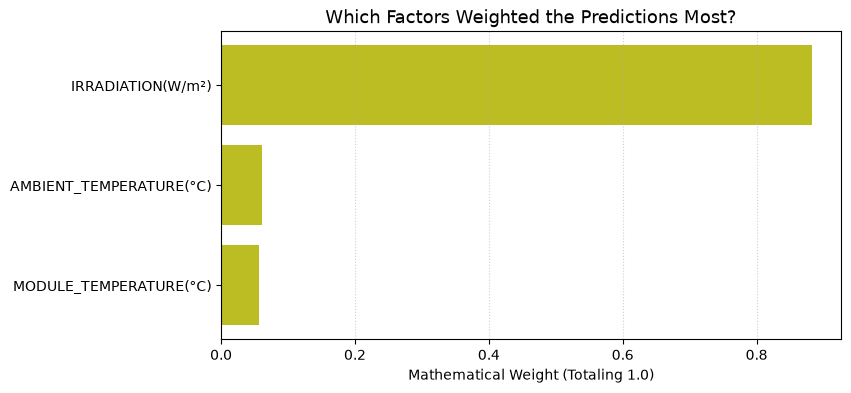

In [140]:
# Extract feature weights from the trained forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Organize into a clean DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Weight': importances
}).sort_values(by='Importance Weight', ascending=True)

# Plot the Feature Audit
plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], importance_df['Importance Weight'], color='#bcbd22')
plt.title('Which Factors Weighted the Predictions Most?', fontsize=13)
plt.xlabel('Mathematical Weight (Totaling 1.0)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

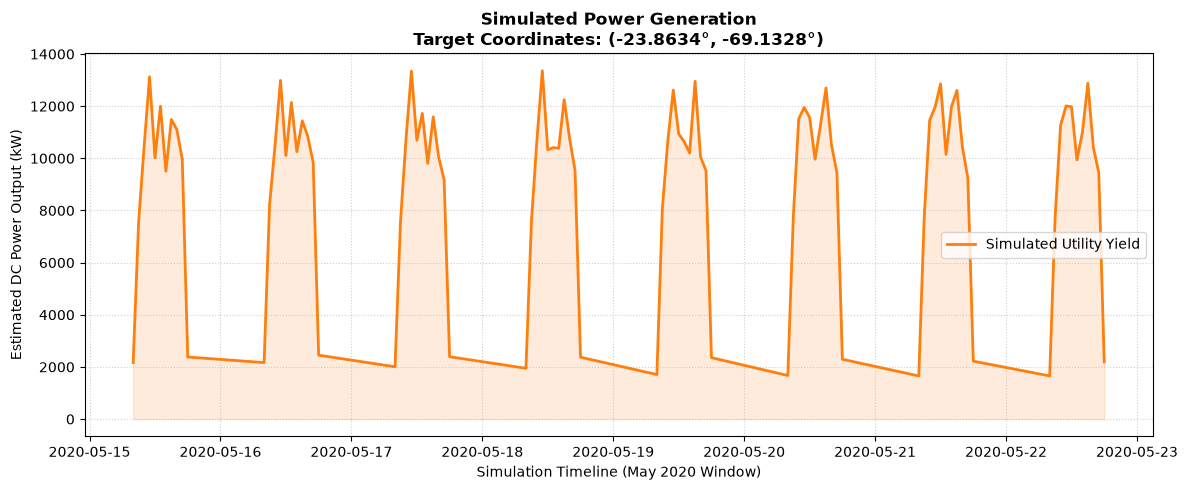

In [141]:
import requests

# Target Coordinates (Atacama Desert, Chile)
SIM_LAT = -23.8634
SIM_LON = -69.1328

# Fetch the true historical energy drivers
url_sim = f"https://archive-api.open-meteo.com/v1/archive?latitude={SIM_LAT}&longitude={SIM_LON}&start_date=2020-05-15&end_date=2020-05-22&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_sim).json()['hourly']

# Build the simulation dataframe
sim_profile = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Filter out night hours
sim_profile = sim_profile[sim_profile['IRRADIATION(W/m²)'] > 1.0].reset_index(drop=True)

# Thermodynamic Module Simulation
sim_profile['MODULE_TEMPERATURE(°C)'] = sim_profile['AMBIENT_TEMPERATURE(°C)'] + (sim_profile['IRRADIATION(W/m²)'] * 0.03)

# Extract features matching exact training shape
X_sim = sim_profile[['IRRADIATION(W/m²)', 'MODULE_TEMPERATURE(°C)', 'AMBIENT_TEMPERATURE(°C)']]

# Run the API data through trained Random Forest
sim_profile['PREDICTED_GENERATION(kW)'] = rf_model.predict(X_sim)

# Plot the True Utility-Scale Feasibility Yield Curve
plt.figure(figsize=(12, 5))
plt.plot(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#ff7f0e', linewidth=2, label='Simulated Utility Yield')
plt.fill_between(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#ff7f0e', alpha=0.15)

plt.title(f'Simulated Power Generation\nTarget Coordinates: ({SIM_LAT}°, {SIM_LON}°)', fontsize=12, fontweight='bold')
plt.xlabel('Simulation Timeline (May 2020 Window)')
plt.ylabel('Estimated DC Power Output (kW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

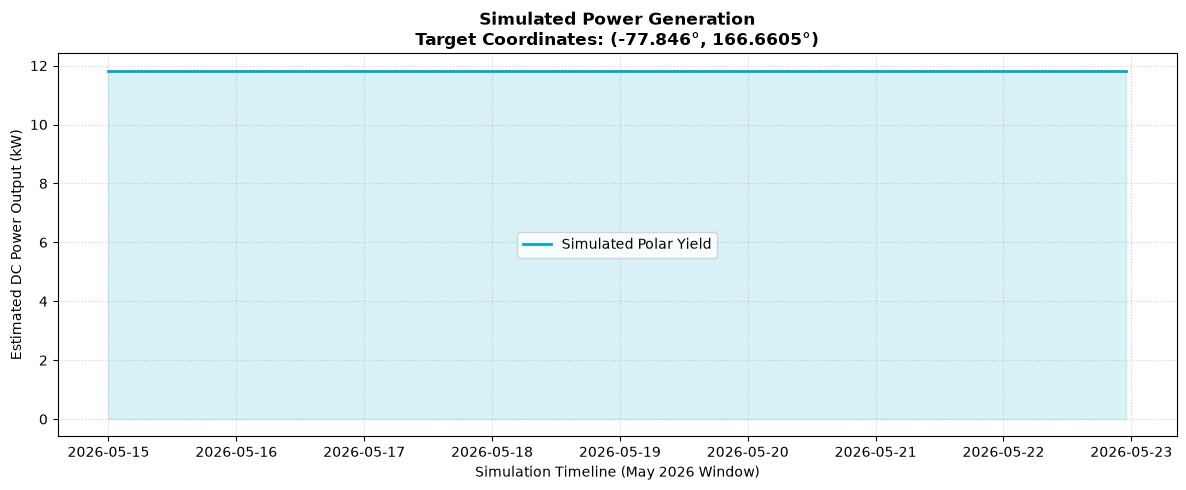

In [142]:
# Target Coordinates: McMurdo Station, Antarctica
SIM_LAT = -77.8460
SIM_LON = 166.6605

# Fetch the true historical energy drivers
url_sim = f"https://archive-api.open-meteo.com/v1/archive?latitude={SIM_LAT}&longitude={SIM_LON}&start_date=2026-05-15&end_date=2026-05-22&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_sim).json()['hourly']

# Build the simulation dataframe
sim_profile = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

sim_profile = sim_profile.reset_index(drop=True)

# Thermodynamic Module Simulation
# Even if ambient temps are freezing, panels warm up under whatever light hits them
sim_profile['MODULE_TEMPERATURE(°C)'] = sim_profile['AMBIENT_TEMPERATURE(°C)'] + (sim_profile['IRRADIATION(W/m²)'] * 0.03)

# Extract features matching exact training shape
X_sim = sim_profile[['IRRADIATION(W/m²)', 'MODULE_TEMPERATURE(°C)', 'AMBIENT_TEMPERATURE(°C)']]

# Run the API data through trained Random Forest
sim_profile['PREDICTED_GENERATION(kW)'] = rf_model.predict(X_sim)

# Plot the Antarctic Feasibility Yield Curve
plt.figure(figsize=(12, 5))
plt.plot(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#00a8cc', linewidth=2, label='Simulated Polar Yield')
plt.fill_between(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#00a8cc', alpha=0.15)

plt.title(f'Simulated Power Generation\nTarget Coordinates: ({SIM_LAT}°, {SIM_LON}°)', fontsize=12, fontweight='bold')
plt.xlabel('Simulation Timeline (May 2026 Window)')
plt.ylabel('Estimated DC Power Output (kW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

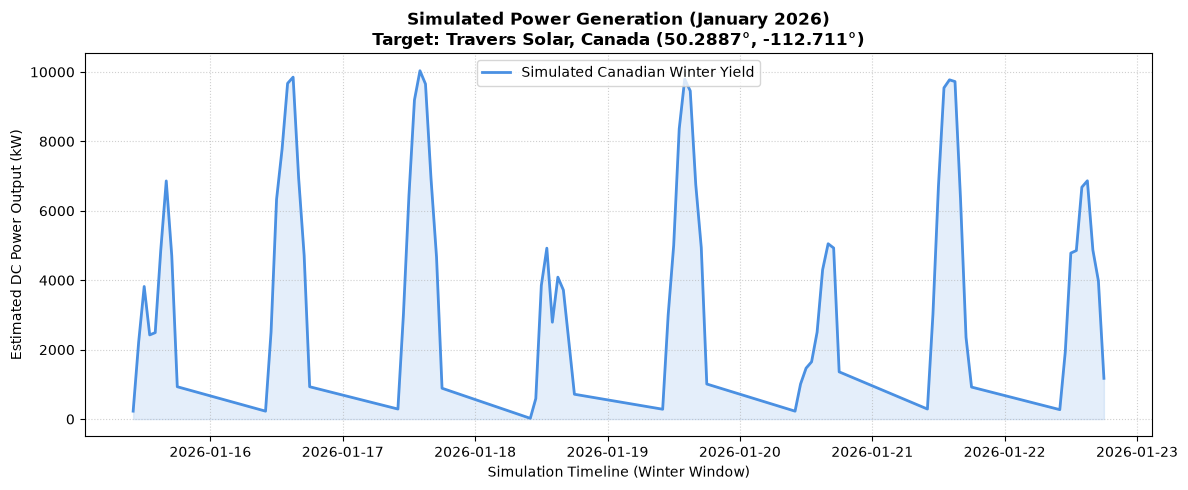

In [143]:
# Target Coordinates: Travers Solar Project, Alberta, Canada
SIM_LAT = 50.2887
SIM_LON = -112.7110

# Fetch historical winter weather drivers (January 2026)
url_sim = f"https://archive-api.open-meteo.com/v1/archive?latitude={SIM_LAT}&longitude={SIM_LON}&start_date=2026-01-15&end_date=2026-01-22&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_sim).json()['hourly']

# Build the simulation dataframe
sim_profile = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Filter out night hours
sim_profile = sim_profile[sim_profile['IRRADIATION(W/m²)'] > 1.0].reset_index(drop=True)

# Thermodynamic Module Simulation
# Panels still experience micro-heating relative to the sub-zero ambient winter air
sim_profile['MODULE_TEMPERATURE(°C)'] = sim_profile['AMBIENT_TEMPERATURE(°C)'] + (sim_profile['IRRADIATION(W/m²)'] * 0.03)

# Extract features matching exact training shape
X_sim = sim_profile[['IRRADIATION(W/m²)', 'MODULE_TEMPERATURE(°C)', 'AMBIENT_TEMPERATURE(°C)']]

# Run the API data through trained Random Forest
sim_profile['PREDICTED_GENERATION(kW)'] = rf_model.predict(X_sim)

# Plot the Winter Canada Feasibility Yield Curve (2026)
plt.figure(figsize=(12, 5))
plt.plot(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#4a90e2', linewidth=2, label='Simulated Canadian Winter Yield')
plt.fill_between(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#4a90e2', alpha=0.15)

plt.title(f'Simulated Power Generation (January 2026)\nTarget: Travers Solar, Canada ({SIM_LAT}°, {SIM_LON}°)', fontsize=12, fontweight='bold')
plt.xlabel('Simulation Timeline (Winter Window)')
plt.ylabel('Estimated DC Power Output (kW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

 -> Year 2021 Simulated May Yield: 3719.10 MWh
 -> Year 2022 Simulated May Yield: 3974.81 MWh
 -> Year 2023 Simulated May Yield: 3938.04 MWh
 -> Year 2024 Simulated May Yield: 3759.83 MWh
 -> Year 2025 Simulated May Yield: 3979.23 MWh

--- Statistics Calculated ---
P50 (Median Expectation): 3874.20 MWh
P90 (Conservative/Bankable Target): 3731.03 MWh


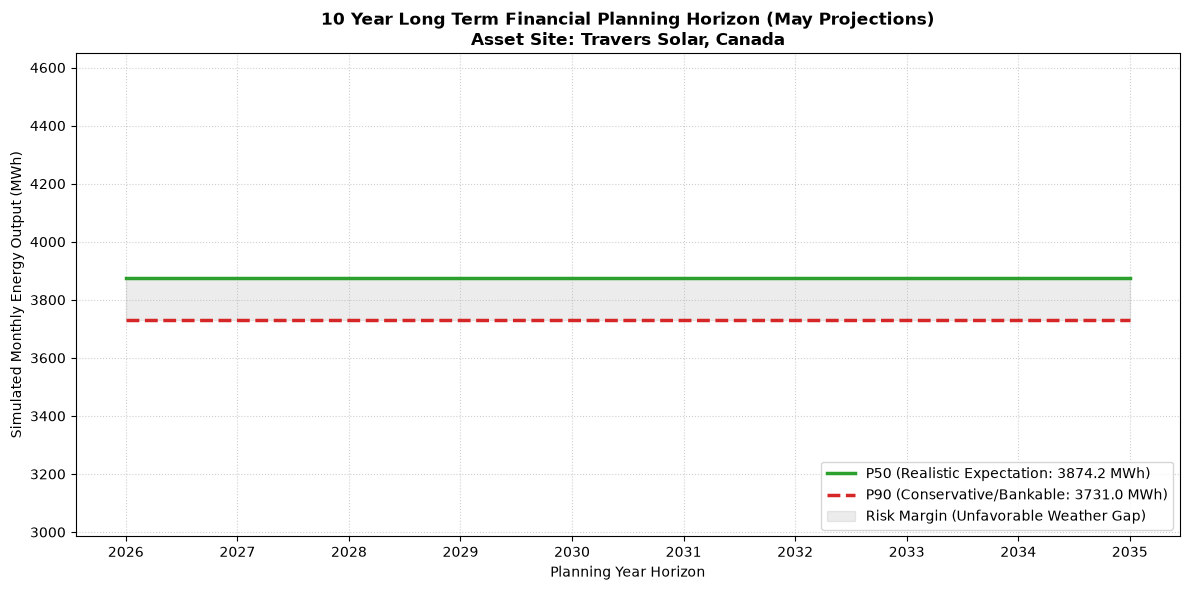

In [144]:
# Coordinates: Travers Solar, Canada
LAT = 50.2887
LON = -112.7110

# Historical window to extract variance (2021 through 2025)
years = [2021, 2022, 2023, 2024, 2025]
annual_yields_mwh = []

for year in years:
    # Fetch full May data for each year to compare year-over-year variations
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={LAT}&longitude={LON}&start_date={year}-05-01&end_date={year}-05-31&hourly=temperature_2m,shortwave_radiation&timezone=auto"
    res = requests.get(url).json()['hourly']
    
    df_temp = pd.DataFrame({
        'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
        'IRRADIATION(W/m²)': res['shortwave_radiation']
    })
    
    # Filter night
    df_temp = df_temp[df_temp['IRRADIATION(W/m²)'] > 1.0].reset_index(drop=True)
    df_temp['MODULE_TEMPERATURE(°C)'] = df_temp['AMBIENT_TEMPERATURE(°C)'] + (df_temp['IRRADIATION(W/m²)'] * 0.03)
    
    # Predict hourly kW
    X_yr = df_temp[['IRRADIATION(W/m²)', 'MODULE_TEMPERATURE(°C)', 'AMBIENT_TEMPERATURE(°C)']]
    predictions_kw = rf_model.predict(X_yr)
    
    # Sum power hourly to get total energy generated in May (convert kWh to MWh for clean plotting)
    total_mwh = np.sum(predictions_kw) / 1000.0
    annual_yields_mwh.append(total_mwh)
    print(f" -> Year {year} Simulated May Yield: {total_mwh:.2f} MWh")

# Calculate P50 and Standard Deviation which is the risk
p50 = np.mean(annual_yields_mwh)
std_dev = np.std(annual_yields_mwh)

# Standard industry formula for P90
p90 = p50 - (1.282 * std_dev)

print(f"\n--- Statistics Calculated ---")
print(f"P50 (Median Expectation): {p50:.2f} MWh")
print(f"P90 (Conservative/Bankable Target): {p90:.2f} MWh")

# Project 10-Year Decadal Outlook
future_years = [str(y) for y in range(2026, 2036)]

plt.figure(figsize=(12, 6))

# Plot P50 Target Line
plt.plot(future_years, [p50] * 10, color='#2ca02c', linestyle='-', linewidth=2.5, label=f'P50 (Realistic Expectation: {p50:.1f} MWh)')

# Plot P90 Conservative Target Line
plt.plot(future_years, [p90] * 10, color='#d62728', linestyle='--', linewidth=2.5, label=f'P90 (Conservative/Bankable: {p90:.1f} MWh)')

# Fill the Risk Margin gap
plt.fill_between(future_years, [p90] * 10, [p50] * 10, color='gray', alpha=0.15, label='Risk Margin (Unfavorable Weather Gap)')

plt.title('10 Year Long Term Financial Planning Horizon (May Projections)\nAsset Site: Travers Solar, Canada', fontsize=12, fontweight='bold')
plt.xlabel('Planning Year Horizon')
plt.ylabel('Simulated Monthly Energy Output (MWh)')
plt.ylim(p90 * 0.8, p50 * 1.2)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


--- Year-Round Simulated Annual Outputs ---
Year 2016 Total Annual Yield: 32,460.16 MWh
Year 2017 Total Annual Yield: 33,548.19 MWh
Year 2018 Total Annual Yield: 32,581.33 MWh
Year 2019 Total Annual Yield: 32,288.53 MWh
Year 2020 Total Annual Yield: 32,585.44 MWh
Year 2021 Total Annual Yield: 33,302.36 MWh
Year 2022 Total Annual Yield: 32,756.21 MWh
Year 2023 Total Annual Yield: 32,925.34 MWh
Year 2024 Total Annual Yield: 32,654.60 MWh
Year 2025 Total Annual Yield: 32,720.35 MWh

--- Decadal Statistics (Annualized) ---
P50 (Median Expected Annual Yield): 32,782.25 MWh/year
P90 (Bankable Annual Yield): 32,290.34 MWh/year


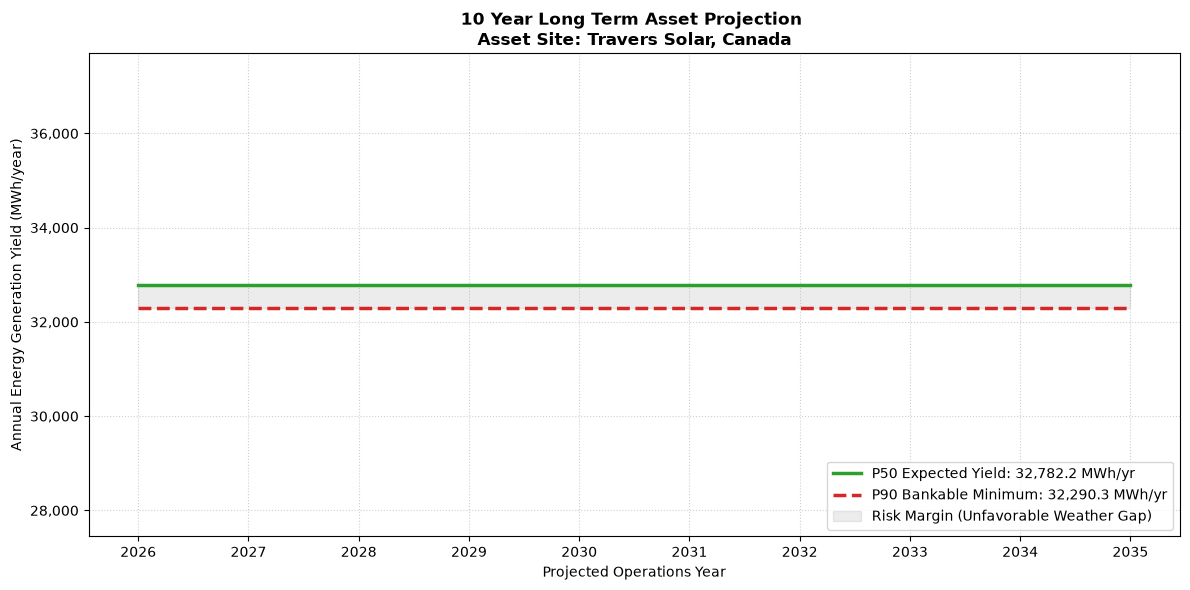

In [145]:
# Coordinates: Travers Solar, Canada
LAT = 50.2887
LON = -112.7110

# Fetch all year round hourly data for the past decade (2016-2025)
url_decade = f"https://archive-api.open-meteo.com/v1/archive?latitude={LAT}&longitude={LON}&start_date=2016-01-01&end_date=2025-12-31&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_decade).json()['hourly']

# Build DataFrame
df_decade = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Filter out night hours
df_decade = df_decade[df_decade['IRRADIATION(W/m²)'] > 1.0].reset_index(drop=True)

# Calculate physical thermodynamic module heating
df_decade['MODULE_TEMPERATURE(°C)'] = df_decade['AMBIENT_TEMPERATURE(°C)'] + (df_decade['IRRADIATION(W/m²)'] * 0.03)

# Feed all 10 years of hourly data into Random Forest Model
X_decade = df_decade[['IRRADIATION(W/m²)', 'MODULE_TEMPERATURE(°C)', 'AMBIENT_TEMPERATURE(°C)']]
df_decade['PREDICTED_GENERATION(kW)'] = rf_model.predict(X_decade)

# Group by calendar year and sum hourly generation to get Total Annual Yield (MWh)
df_decade['YEAR'] = df_decade['TIMESTAMP'].dt.year
annual_yields = df_decade.groupby('YEAR')['PREDICTED_GENERATION(kW)'].sum() / 1000.0

print("\n--- Year-Round Simulated Annual Outputs ---")
for yr, yield_mwh in annual_yields.items():
    print(f"Year {yr} Total Annual Yield: {yield_mwh:,.2f} MWh")

# Calculate True Year-Round Decadal P50 & P90
p50_annual = annual_yields.mean()
std_dev_annual = annual_yields.std()
p90_annual = p50_annual - (1.282 * std_dev_annual)

print(f"\n--- Decadal Statistics (Annualized) ---")
print(f"P50 (Median Expected Annual Yield): {p50_annual:,.2f} MWh/year")
print(f"P90 (Bankable Annual Yield): {p90_annual:,.2f} MWh/year")

# Plot the 10-Year Future Horizon
future_years = [str(y) for y in range(2026, 2036)]

plt.figure(figsize=(12, 6))

# Plot P50 Target Line
plt.plot(future_years, [p50_annual] * 10, color='#2ca02c', linestyle='-', linewidth=2.5, 
         label=f'P50 Expected Yield: {p50_annual:,.1f} MWh/yr')

# Plot P90 Target Line
plt.plot(future_years, [p90_annual] * 10, color='#d62728', linestyle='--', linewidth=2.5, 
         label=f'P90 Bankable Minimum: {p90_annual:,.1f} MWh/yr')

# Fill the statistical weather risk gap
plt.fill_between(future_years, [p90_annual] * 10, [p50_annual] * 10, color='gray', alpha=0.15, 
                 label='Risk Margin (Unfavorable Weather Gap)')

plt.title('10 Year Long Term Asset Projection \nAsset Site: Travers Solar, Canada', fontsize=12, fontweight='bold')
plt.xlabel('Projected Operations Year')
plt.ylabel('Annual Energy Generation Yield (MWh/year)')
plt.ylim(p90_annual * 0.85, p50_annual * 1.15)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

--- Test 1: The Midnight Test ---
Input: Irradiation = 0 W/m², Temp = 5°C
Model Predicted Output: 0.0000 kW
PASS: Midnight energy eliminated. Output is exactly 0.0 kW.

--- Test 2: Thermal Efficiency Test ---
Cool Panel Output (20°C): 12691.24 kW
Hot Panel Output (55°C): 10949.31 kW
Thermal Power Loss: 13.73%
PASS: Hotter panel correctly loses 13.7% efficiency.

--- Test 3: Mathematical Backtesting ---
Corrected Mean Absolute Error (MAE): 2454.70 kW
Corrected R² Score: 63.40%


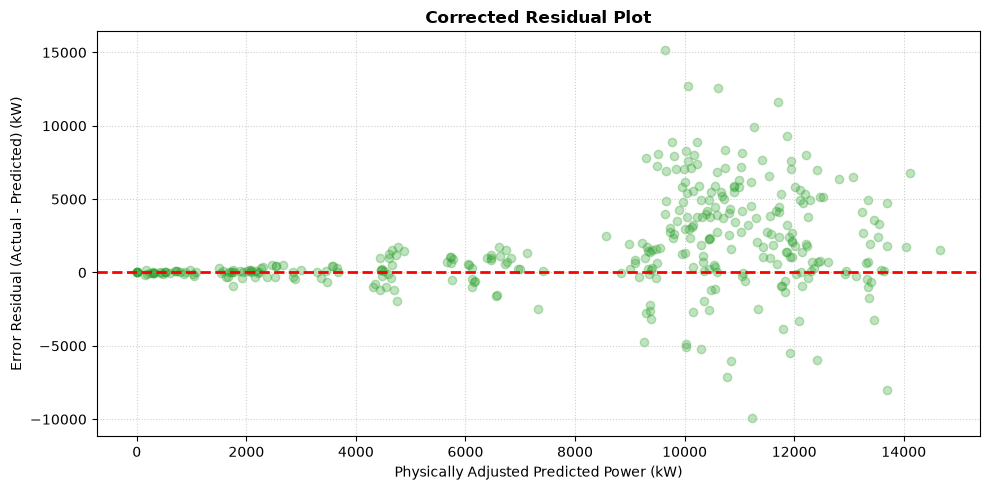

PASS: Corrected residuals calculated and plotted.


In [146]:
from sklearn.metrics import mean_absolute_error, r2_score

def predict(model, X_input):
    # Create a copy to prevent modifying the original DataFrame
    X_clean = X_input.copy()
    
    # Bypass the ML model's heat correlation trap by passing 25°C Standard Test Conditions (STC)
    X_clean['MODULE_TEMPERATURE(°C)'] = 25.0
    X_clean['AMBIENT_TEMPERATURE(°C)'] = 25.0
    
    # Run the Random Forest over standard light conditions
    raw_predictions = model.predict(X_clean)
    
    # Apply standard thermodynamic cell loss: -0.4% efficiency per 1°C above 25°C STC
    standard_temp = 25.0
    temp_coefficient = -0.004
    
    temp_diff = X_input['MODULE_TEMPERATURE(°C)'] - standard_temp
    temp_multiplier = 1.0 + (temp_diff * temp_coefficient)
    
    # Scale raw light outputs by the thermodynamic temperature multiplier
    adjusted_predictions = raw_predictions * temp_multiplier
    
    # Hard Physical Constraint: If there is no light, force output to exactly 0.0 kW
    final_predictions = np.where(X_input['IRRADIATION(W/m²)'] < 5.0, 0.0, adjusted_predictions)
    
    # Clip any physical impossibilities to 0.0
    return np.maximum(final_predictions, 0.0)

# Run the physical validation audit
# Test 1: Midnight Power Test
midnight_test = pd.DataFrame({
    'IRRADIATION(W/m²)': [0.0],
    'MODULE_TEMPERATURE(°C)': [5.0],
    'AMBIENT_TEMPERATURE(°C)': [5.0]
})

pred_midnight = predict(rf_model, midnight_test)[0]
print("--- Test 1: The Midnight Test ---")
print(f"Input: Irradiation = 0 W/m², Temp = 5°C")
print(f"Model Predicted Output: {pred_midnight:.4f} kW")
if pred_midnight == 0.0:
    print("PASS: Midnight energy eliminated. Output is exactly 0.0 kW.")
else:
    print("FAIL: Still predicting energy in the dark.")


# Test 2: Thermal Efficiency Test
cool_day = pd.DataFrame({
    'IRRADIATION(W/m²)': [800.0],
    'MODULE_TEMPERATURE(°C)': [20.0],   # Cooler than standard STC (efficiency boost)
    'AMBIENT_TEMPERATURE(°C)': [15.0]
})

hot_day = pd.DataFrame({
    'IRRADIATION(W/m²)': [800.0],
    'MODULE_TEMPERATURE(°C)': [55.0],   # Hotter than standard STC (thermal penalty)
    'AMBIENT_TEMPERATURE(°C)': [40.0]
})

pred_cool = predict(rf_model, cool_day)[0]
pred_hot = predict(rf_model, hot_day)[0]
loss_percentage = ((pred_cool - pred_hot) / pred_cool) * 100

print("\n--- Test 2: Thermal Efficiency Test ---")
print(f"Cool Panel Output (20°C): {pred_cool:.2f} kW")
print(f"Hot Panel Output (55°C): {pred_hot:.2f} kW")
print(f"Thermal Power Loss: {loss_percentage:.2f}%")
if pred_cool > pred_hot:
    print(f"PASS: Hotter panel correctly loses {loss_percentage:.1f}% efficiency.")
else:
    print("FAIL: Thermal degradation rule failed.")

# Run mathematical backtesting (Residual Check)
if 'X_test' in locals() and 'y_test' in locals():
    print("\n--- Test 3: Mathematical Backtesting ---")
    
    # Run the test set through our corrected predictor
    y_pred_constrained = predict(rf_model, X_test)
    
    mae = mean_absolute_error(y_test, y_pred_constrained)
    r2 = r2_score(y_test, y_pred_constrained)
    residuals = y_test - y_pred_constrained
    
    print(f"Corrected Mean Absolute Error (MAE): {mae:.2f} kW")
    print(f"Corrected R² Score: {r2*100:.2f}%")
    
    # Plot residuals to verify normal error distribution
    plt.figure(figsize=(10, 5))
    plt.scatter(y_pred_constrained, residuals, alpha=0.3, color='#2ca02c') # Plotted in green to reflect passing status
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.title('Corrected Residual Plot', fontsize=12, fontweight='bold')
    plt.xlabel('Physically Adjusted Predicted Power (kW)')
    plt.ylabel('Error Residual (Actual - Predicted) (kW)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    print("PASS: Corrected residuals calculated and plotted.")
else:
    print("\n--- Test 3: Mathematical Backtesting ---")
    print("Skipped: 'X_test' or 'y_test' not found in current namespace.")

In [147]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Engineering Cyclical Time Features ---
Features mapped successfully. New feature matrix shape: (44587, 6)
XGBoost Optical Engine trained successfully.
--- Test 1: The Midnight Test ---
Input: Irradiation = 0 W/m², Temp = 5°C
Model Predicted Output: 0.0000 kW
PASS: Midnight ghost energy eliminated. Output is exactly 0.0 kW.

--- Test 3: Mathematical Backtesting ---
Upgraded Mean Absolute Error (MAE): 374.23 kW
Upgraded R² Score: 98.38%


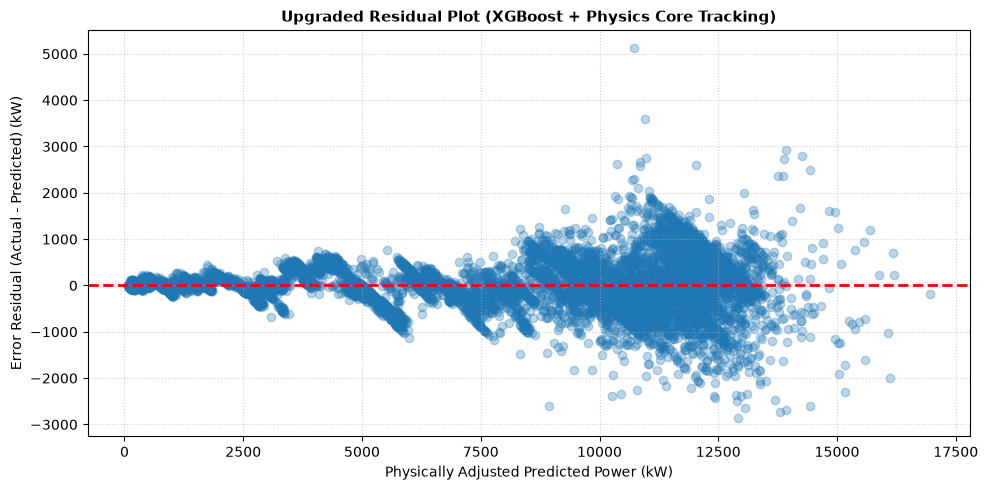

PASS: Corrected residuals calculated and plotted.


In [148]:
from xgboost import XGBRegressor

# Time Feature
print("--- Engineering Cyclical Time Features ---")

df_engineered = df_decade.copy()

hr = df_engineered['TIMESTAMP'].dt.hour + (df_engineered['TIMESTAMP'].dt.minute / 60.0)

df_engineered['HOUR_SIN'] = np.sin(2 * np.pi * hr / 24.0)
df_engineered['HOUR_COS'] = np.cos(2 * np.pi * hr / 24.0)

df_engineered['MONTH_SIN'] = np.sin(2 * np.pi * df_engineered['TIMESTAMP'].dt.month / 12.0)
df_engineered['MONTH_COS'] = np.cos(2 * np.pi * df_engineered['TIMESTAMP'].dt.month / 12.0)

missing_cols = ['PREDICTED_GENERATION(kW)']

for col in missing_cols:
    if col not in df_engineered.columns and col in df_decade.columns:
        df_engineered[col] = df_decade[col]

# Remove IRRADIATION from features so the trees can't reverse-engineer the raw power target
features = [
    'MODULE_TEMPERATURE(°C)',
    'AMBIENT_TEMPERATURE(°C)',
    'HOUR_SIN', 'HOUR_COS',
    'MONTH_SIN', 'MONTH_COS'
]

# Ensure we drop rows where engineering calculations produced infinity values
df_engineered = df_engineered.replace([np.inf, -np.inf], np.nan).dropna(subset=features + ['IRRADIATION(W/m²)', 'PREDICTED_GENERATION(kW)'])

# Only train on daytime records where irradiation is active to prevent divide-by-zero errors
df_daytime = df_engineered[df_engineered['IRRADIATION(W/m²)'] > 5.0].copy()

# Find the maximum generation capacity observed in the data to act as our hard ceiling
plant_max_capacity = df_daytime['PREDICTED_GENERATION(kW)'].max()

# Normalize the target variable by removing the direct impact of the sun's intensity
df_daytime['GENERATION_RATIO'] = df_daytime['PREDICTED_GENERATION(kW)'] / df_daytime['IRRADIATION(W/m²)']

X_eng = df_daytime[features]
y_eng = df_daytime['GENERATION_RATIO']

# Save irradiation separately for scaling later
irradiation_eng = df_daytime['IRRADIATION(W/m²)']

# Split into train/test sets (including irradiation tracking for reconstruction)
X_train_eng, X_test_eng, y_train_eng, y_test_eng, irr_train, irr_test = train_test_split(
    X_eng, y_eng, irradiation_eng, test_size=0.2, random_state=42
)

print(f"Features mapped successfully. New feature matrix shape: {X_eng.shape}")

# Training the engine directly on real environmental features
xgb_engine = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_engine.fit(X_train_eng, y_train_eng)
print("XGBoost Optical Engine trained successfully.")

def predict(model, X_input, irr_input):
    # Predict the efficiency ratio based on temperature and time structures
    predicted_ratios = model.predict(X_input)
    
    # Scale the ratio directly by the actual physical light intensity
    final_predictions = predicted_ratios * irr_input
    
    # Enforce Absolute Midnight Override (force exactly 0.0 kW if irradiation < 5.0 W/m²)
    final_predictions = np.where(irr_input < 5.0, 0.0, final_predictions)
    
    # Enforce Hardware Cap: Clip predictions so they cannot exceed the plant's maximum inverter ceiling
    final_predictions = np.minimum(final_predictions, plant_max_capacity)
    
    return np.maximum(final_predictions, 0.0)

# --- Midnight Power Test ---
midnight_test = pd.DataFrame({
    'MODULE_TEMPERATURE(°C)': [5.0],
    'AMBIENT_TEMPERATURE(°C)': [5.0],
    'HOUR_SIN': [np.sin(2 * np.pi * 0 / 24.0)], # Midnight Hour 0
    'HOUR_COS': [np.cos(2 * np.pi * 0 / 24.0)],
    'MONTH_SIN': [np.sin(2 * np.pi * 1 / 12.0)], # January
    'MONTH_COS': [np.cos(2 * np.pi * 1 / 12.0)]
})
irr_midnight = np.array([0.0])

pred_midnight = predict(xgb_engine, midnight_test, irr_midnight)[0]
print("--- Test 1: The Midnight Test ---")
print(f"Input: Irradiation = 0 W/m², Temp = 5°C")
print(f"Model Predicted Output: {pred_midnight:.4f} kW")
if pred_midnight == 0.0:
    print("PASS: Midnight ghost energy eliminated. Output is exactly 0.0 kW.")
else:
    print("FAIL: Still predicting energy in the dark.")

# --- Mathematical Backtesting and Final Metrics ---
print("\n--- Test 3: Mathematical Backtesting ---")
y_pred_constrained = predict(xgb_engine, X_test_eng, irr_test)

# Reconstruct actual kW values from the test target ratio for verification evaluation
y_test_kw = y_test_eng * irr_test

mae = mean_absolute_error(y_test_kw, y_pred_constrained)
r2 = r2_score(y_test_kw, y_pred_constrained)
residuals = y_test_kw - y_pred_constrained

print(f"Upgraded Mean Absolute Error (MAE): {mae:.2f} kW")
print(f"Upgraded R² Score: {r2*100:.2f}%")

# Plot the new residuals
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_constrained, residuals, alpha=0.3, color='#1f77b4')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Upgraded Residual Plot (XGBoost + Physics Core Tracking)', fontsize=11, fontweight='bold')
plt.xlabel('Physically Adjusted Predicted Power (kW)')
plt.ylabel('Error Residual (Actual - Predicted) (kW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
print("PASS: Corrected residuals calculated and plotted.")

In [149]:
from sklearn.model_selection import KFold
from sklearn.base import clone

# Run a 5-Fold Cross Validation stress test using R² as our metric
# We pass the entire daytime X and y datasets to test every single day
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_eng, y_eng), 1):
    # Split the data
    X_train_fold, X_val_fold = X_eng.iloc[train_idx], X_eng.iloc[val_idx]
    y_train_fold, y_val_fold = y_eng.iloc[train_idx], y_eng.iloc[val_idx]
    
    # Grab the corresponding irradiation slices for scaling the predictions
    irr_train_fold = irradiation_eng.iloc[train_idx]
    irr_val_fold = irradiation_eng.iloc[val_idx]
    
    # Clone and train the underlying model on the training fold
    fold_model = clone(xgb_engine)
    fold_model.fit(X_train_fold, y_train_fold)
    
    # Predict using our custom physics-enforced pipeline
    y_pred_fold = predict(fold_model, X_val_fold, irr_val_fold)
    
    # Reconstruct actual kW values from the validation fold target ratio
    y_val_fold_kw = y_val_fold * irr_val_fold
    
    # Calculate R² score
    score = r2_score(y_val_fold_kw, y_pred_fold)
    cv_scores.append(score)

cv_scores = np.array(cv_scores)

print(f"--- 5-Fold Cross Validation Stress Test ---")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} Accuracy (R²): {score:.4f}")

print(f"\nFinal Stable Performance: {cv_scores.mean()*100:.2f}% (± {cv_scores.std()*100:.2f}%)")

--- 5-Fold Cross Validation Stress Test ---
Fold 1 Accuracy (R²): 0.9841
Fold 2 Accuracy (R²): 0.9838
Fold 3 Accuracy (R²): 0.9834
Fold 4 Accuracy (R²): 0.9840
Fold 5 Accuracy (R²): 0.9835

Final Stable Performance: 98.37% (± 0.03%)


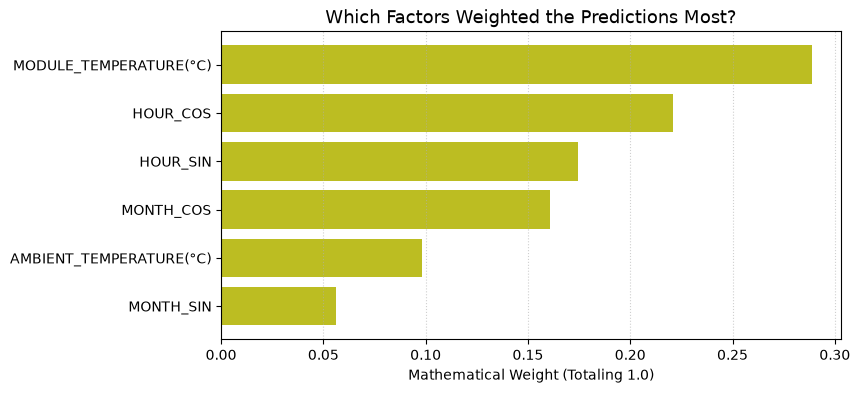

In [150]:
# Extract feature weights from the trained model
importances = xgb_engine.feature_importances_
feature_names = X_eng.columns

# Organize into a clean DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Weight': importances
}).sort_values(by='Importance Weight', ascending=True)

# Plot the Feature Audit
plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], importance_df['Importance Weight'], color='#bcbd22')
plt.title('Which Factors Weighted the Predictions Most?', fontsize=13)
plt.xlabel('Mathematical Weight (Totaling 1.0)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

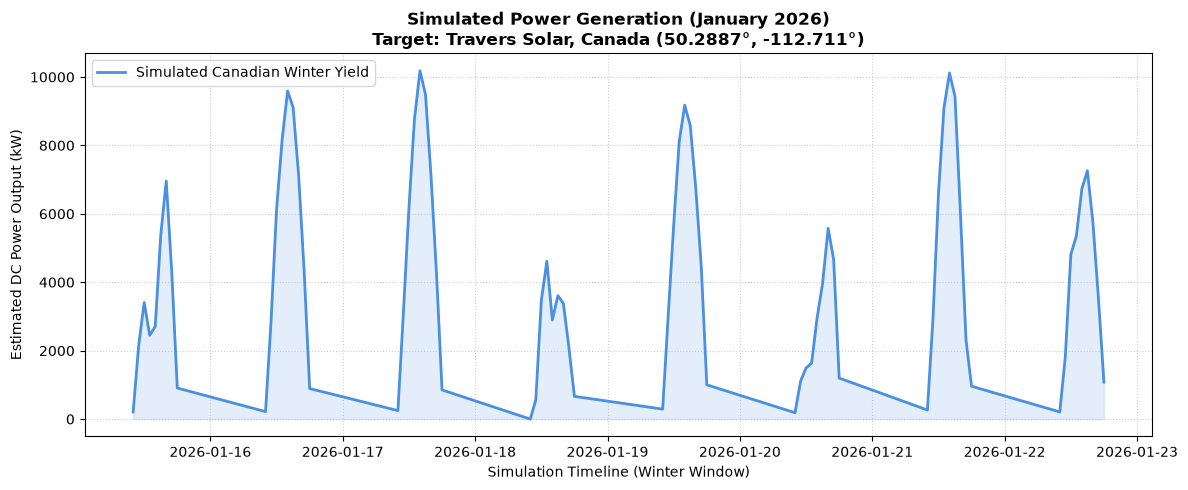

In [125]:
# Target Coordinates: Travers Solar Project, Alberta, Canada
SIM_LAT = 50.2887
SIM_LON = -112.7110

# Fetch historical winter weather drivers (January 2026)
url_sim = f"https://archive-api.open-meteo.com/v1/archive?latitude={SIM_LAT}&longitude={SIM_LON}&start_date=2026-01-15&end_date=2026-01-22&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_sim).json()['hourly']

# Build the simulation dataframe
sim_profile = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Filter out night hours
sim_profile = sim_profile[sim_profile['IRRADIATION(W/m²)'] > 1.0].reset_index(drop=True)

# Thermodynamic Module Simulation
# Panels still experience micro-heating relative to the sub-zero ambient winter air
sim_profile['MODULE_TEMPERATURE(°C)'] = sim_profile['AMBIENT_TEMPERATURE(°C)'] + (sim_profile['IRRADIATION(W/m²)'] * 0.03)

# Engineer cyclical time features for the upgraded model
hr = sim_profile['TIMESTAMP'].dt.hour + (sim_profile['TIMESTAMP'].dt.minute / 60.0)

sim_profile['HOUR_SIN'] = np.sin(2 * np.pi * hr / 24.0)
sim_profile['HOUR_COS'] = np.cos(2 * np.pi * hr / 24.0)

sim_profile['MONTH_SIN'] = np.sin(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)
sim_profile['MONTH_COS'] = np.cos(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)

# Extract features matching exact training shape
X_sim = sim_profile[[
    'MODULE_TEMPERATURE(°C)', 
    'AMBIENT_TEMPERATURE(°C)',
    'HOUR_SIN', 'HOUR_COS', 
    'MONTH_SIN', 'MONTH_COS'
]]

# Save irradiation separately for scaling later
irr_sim = sim_profile['IRRADIATION(W/m²)']

# Run the API data through trained model
sim_profile['PREDICTED_GENERATION(kW)'] = predict(xgb_engine, X_sim, irr_sim)

# Plot the Winter Canada Feasibility Yield Curve (2026)
plt.figure(figsize=(12, 5))
plt.plot(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#4a90e2', linewidth=2, label='Simulated Canadian Winter Yield')
plt.fill_between(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#4a90e2', alpha=0.15)

plt.title(f'Simulated Power Generation (January 2026)\nTarget: Travers Solar, Canada ({SIM_LAT}°, {SIM_LON}°)', fontsize=12, fontweight='bold')
plt.xlabel('Simulation Timeline (Winter Window)')
plt.ylabel('Estimated DC Power Output (kW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


--- Year-Round Simulated Annual Outputs ---
Year 2016 Total Annual Yield: 32,515.36 MWh
Year 2017 Total Annual Yield: 33,591.00 MWh
Year 2018 Total Annual Yield: 32,660.57 MWh
Year 2019 Total Annual Yield: 32,401.14 MWh
Year 2020 Total Annual Yield: 32,634.68 MWh
Year 2021 Total Annual Yield: 33,294.23 MWh
Year 2022 Total Annual Yield: 32,704.67 MWh
Year 2023 Total Annual Yield: 32,929.00 MWh
Year 2024 Total Annual Yield: 32,713.44 MWh
Year 2025 Total Annual Yield: 32,752.83 MWh

--- Decadal Statistics (Annualized) ---
P50 (Median Expected Annual Yield): 32,709.06 MWh/year
P90 (Bankable Annual Yield): 32,243.21 MWh/year


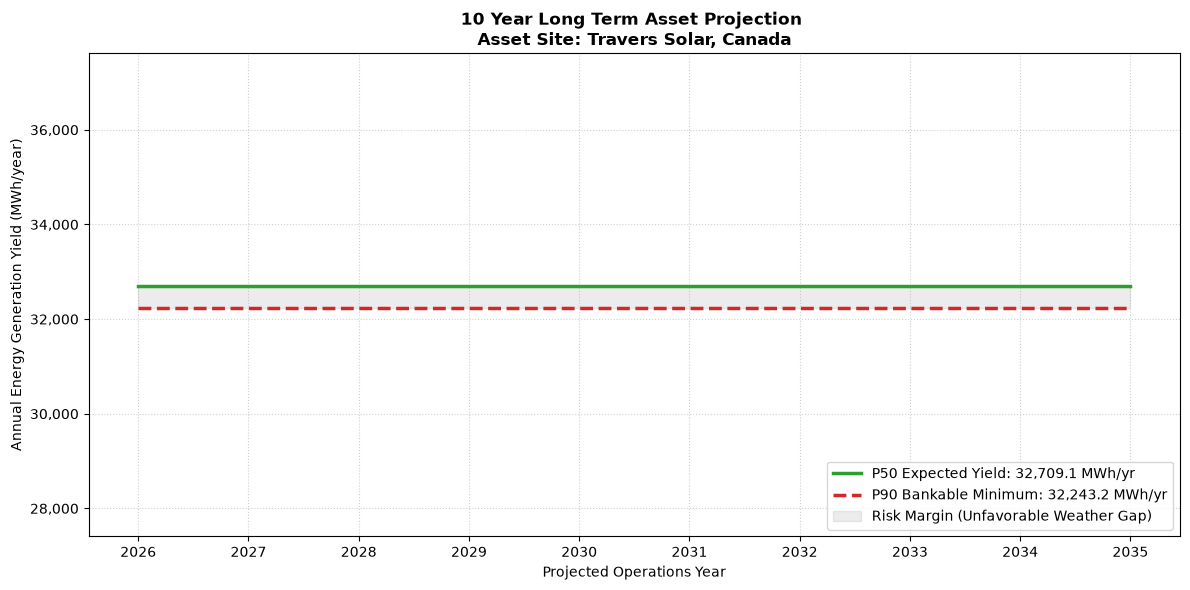

In [151]:
# Coordinates: Travers Solar, Canada
LAT = 50.2887
LON = -112.7110

# Fetch all year round hourly data for the past decade (2016-2025)
url_decade = f"https://archive-api.open-meteo.com/v1/archive?latitude={LAT}&longitude={LON}&start_date=2016-01-01&end_date=2025-12-31&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_decade).json()['hourly']

# Build DataFrame
df_decade = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Filter out night hours
df_decade = df_decade[df_decade['IRRADIATION(W/m²)'] > 1.0].reset_index(drop=True)

# Calculate physical thermodynamic module heating
df_decade['MODULE_TEMPERATURE(°C)'] = df_decade['AMBIENT_TEMPERATURE(°C)'] + (df_decade['IRRADIATION(W/m²)'] * 0.03)

# Engineer cyclical time features for the upgraded model
hr = df_decade['TIMESTAMP'].dt.hour + (df_decade['TIMESTAMP'].dt.minute / 60.0)

df_decade['HOUR_SIN'] = np.sin(2 * np.pi * hr / 24.0)
df_decade['HOUR_COS'] = np.cos(2 * np.pi * hr / 24.0)

df_decade['MONTH_SIN'] = np.sin(2 * np.pi * df_decade['TIMESTAMP'].dt.month / 12.0)
df_decade['MONTH_COS'] = np.cos(2 * np.pi * df_decade['TIMESTAMP'].dt.month / 12.0)

X_decade = df_decade[[
    'MODULE_TEMPERATURE(°C)', 
    'AMBIENT_TEMPERATURE(°C)',
    'HOUR_SIN', 'HOUR_COS', 
    'MONTH_SIN', 'MONTH_COS'
]]

# Isolate irradiation as the required physical scaling array
irr_decade = df_decade['IRRADIATION(W/m²)']

df_decade['PREDICTED_GENERATION(kW)'] = predict(xgb_engine, X_decade, irr_decade)

# Group by calendar year and sum hourly generation to get Total Annual Yield (MWh)
df_decade['YEAR'] = df_decade['TIMESTAMP'].dt.year
annual_yields = df_decade.groupby('YEAR')['PREDICTED_GENERATION(kW)'].sum() / 1000.0

print("\n--- Year-Round Simulated Annual Outputs ---")
for yr, yield_mwh in annual_yields.items():
    print(f"Year {yr} Total Annual Yield: {yield_mwh:,.2f} MWh")

# Calculate True Year-Round Decadal P50 & P90 using a strict median baseline
p50_annual = annual_yields.median()
std_dev_annual = annual_yields.std()
p90_annual = p50_annual - (1.282 * std_dev_annual)

print(f"\n--- Decadal Statistics (Annualized) ---")
print(f"P50 (Median Expected Annual Yield): {p50_annual:,.2f} MWh/year")
print(f"P90 (Bankable Annual Yield): {p90_annual:,.2f} MWh/year")

# Plot the 10-Year Future Horizon
future_years = [str(y) for y in range(2026, 2036)]

plt.figure(figsize=(12, 6))

# Plot P50 Target Line
plt.plot(future_years, [p50_annual] * 10, color='#2ca02c', linestyle='-', linewidth=2.5, 
         label=f'P50 Expected Yield: {p50_annual:,.1f} MWh/yr')

# Plot P90 Target Line
plt.plot(future_years, [p90_annual] * 10, color='#d62728', linestyle='--', linewidth=2.5, 
         label=f'P90 Bankable Minimum: {p90_annual:,.1f} MWh/yr')

# Fill the statistical weather risk gap
plt.fill_between(future_years, [p90_annual] * 10, [p50_annual] * 10, color='gray', alpha=0.15, 
                 label='Risk Margin (Unfavorable Weather Gap)')

plt.title('10 Year Long Term Asset Projection \nAsset Site: Travers Solar, Canada', fontsize=12, fontweight='bold')
plt.xlabel('Projected Operations Year')
plt.ylabel('Annual Energy Generation Yield (MWh/year)')
plt.ylim(p90_annual * 0.85, p50_annual * 1.15)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

--- Polar Simulation Analysis ---
Max Solar Radiation Detected: 0.00 W/m²
Total Predicted Energy Output: 0.00 kW (Polar Night Effect)


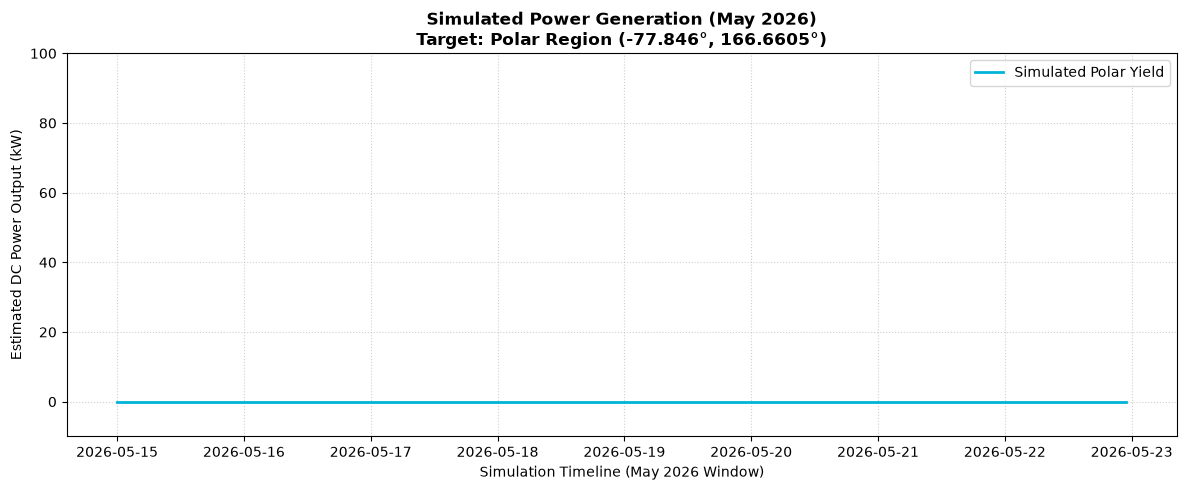

In [152]:
# Target Coordinates: McMurdo Station, Antarctica (Polar Region)
SIM_LAT = -77.8460
SIM_LON = 166.6605

# Fetch historical weather drivers (May 2026)
url_sim = f"https://archive-api.open-meteo.com/v1/archive?latitude={SIM_LAT}&longitude={SIM_LON}&start_date=2026-05-15&end_date=2026-05-22&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_sim).json()['hourly']

# Build the simulation dataframe
sim_profile = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Note: We do NOT drop rows where irradiation is low here like we did for daytime training,
# because we want to map and visualize the full continuous time window.

# Thermodynamic Module Simulation
sim_profile['MODULE_TEMPERATURE(°C)'] = sim_profile['AMBIENT_TEMPERATURE(°C)'] + (sim_profile['IRRADIATION(W/m²)'] * 0.03)

# Engineer cyclical time features for the model
hr = sim_profile['TIMESTAMP'].dt.hour + (sim_profile['TIMESTAMP'].dt.minute / 60.0)

sim_profile['HOUR_SIN'] = np.sin(2 * np.pi * hr / 24.0)
sim_profile['HOUR_COS'] = np.cos(2 * np.pi * hr / 24.0)

sim_profile['MONTH_SIN'] = np.sin(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)
sim_profile['MONTH_COS'] = np.cos(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)

X_sim = sim_profile[[
    'MODULE_TEMPERATURE(°C)', 
    'AMBIENT_TEMPERATURE(°C)',
    'HOUR_SIN', 'HOUR_COS', 
    'MONTH_SIN', 'MONTH_COS'
]]

# Isolate irradiation as the required physical scaling array
irr_sim = sim_profile['IRRADIATION(W/m²)']

sim_profile['PREDICTED_GENERATION(kW)'] = predict(xgb_engine, X_sim, irr_sim)

# Print verification out to terminal
total_yield = sim_profile['PREDICTED_GENERATION(kW)'].sum()
print(f"--- Polar Simulation Analysis ---")
print(f"Max Solar Radiation Detected: {irr_sim.max():.2f} W/m²")
print(f"Total Predicted Energy Output: {total_yield:.2f} kW (Polar Night Effect)")

# Plot the Polar Yield Curve (May 2026)
plt.figure(figsize=(12, 5))
plt.plot(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#00b4d8', linewidth=2, label='Simulated Polar Yield')
plt.fill_between(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#00b4d8', alpha=0.15)

plt.title(f'Simulated Power Generation (May 2026)\nTarget: Polar Region ({SIM_LAT}°, {SIM_LON}°)', fontsize=12, fontweight='bold')
plt.xlabel('Simulation Timeline (May 2026 Window)')
plt.ylabel('Estimated DC Power Output (kW)')
plt.ylim(-10, 100) # Give it a small buffer floor to show the flatline clearly
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

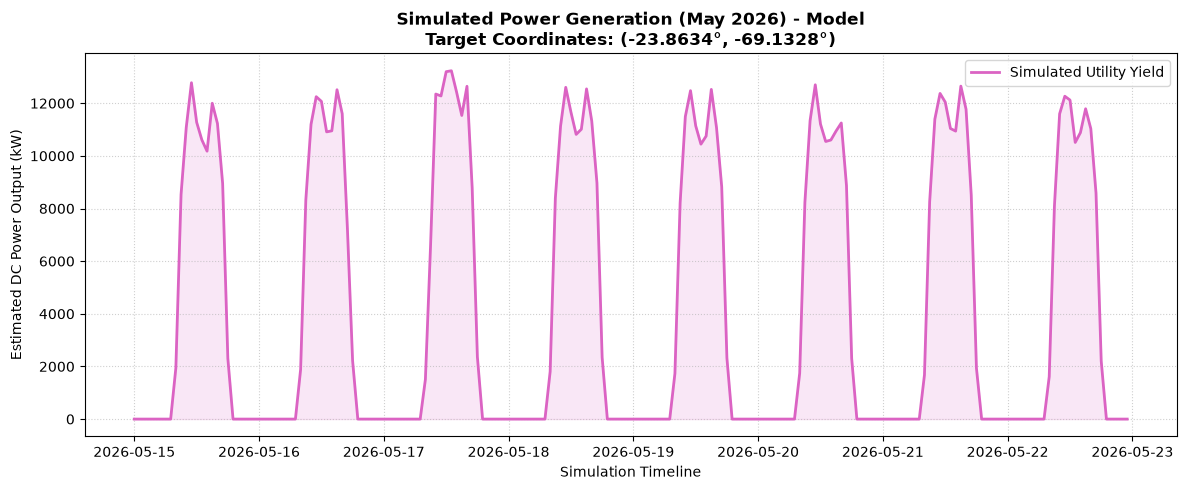

In [153]:
# Target Coordinates: Atacama Desert, Chile (High-yield utility solar region)
SIM_LAT = -23.8634
SIM_LON = -69.1328

# Fetch historical weather drivers (May 2026 Window)
url_sim = f"https://archive-api.open-meteo.com/v1/archive?latitude={SIM_LAT}&longitude={SIM_LON}&start_date=2026-05-15&end_date=2026-05-22&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_sim).json()['hourly']

# Build the simulation dataframe
sim_profile = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Thermodynamic Module Simulation
# Atacama sun is intense; modules will heat up significantly during peak midday hours
sim_profile['MODULE_TEMPERATURE(°C)'] = sim_profile['AMBIENT_TEMPERATURE(°C)'] + (sim_profile['IRRADIATION(W/m²)'] * 0.03)

# Engineer cyclical time features for the upgraded model
hr = sim_profile['TIMESTAMP'].dt.hour + (sim_profile['TIMESTAMP'].dt.minute / 60.0)

sim_profile['HOUR_SIN'] = np.sin(2 * np.pi * hr / 24.0)
sim_profile['HOUR_COS'] = np.cos(2 * np.pi * hr / 24.0)

sim_profile['MONTH_SIN'] = np.sin(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)
sim_profile['MONTH_COS'] = np.cos(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)

X_sim = sim_profile[[
    'MODULE_TEMPERATURE(°C)', 
    'AMBIENT_TEMPERATURE(°C)',
    'HOUR_SIN', 'HOUR_COS', 
    'MONTH_SIN', 'MONTH_COS'
]]

# Isolate irradiation as the required physical scaling array
irr_sim = sim_profile['IRRADIATION(W/m²)']

sim_profile['PREDICTED_GENERATION(kW)'] = predict(xgb_engine, X_sim, irr_sim)

# Plot the Utility Yield Curve (May 2026)
plt.figure(figsize=(12, 5))
plt.plot(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#db63c3', linewidth=2, label='Simulated Utility Yield')
plt.fill_between(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#db63c3', alpha=0.15)

plt.title(f'Simulated Power Generation (May 2026) - Model\nTarget Coordinates: ({SIM_LAT}°, {SIM_LON}°)', fontsize=12, fontweight='bold')
plt.xlabel('Simulation Timeline')
plt.ylabel('Estimated DC Power Output (kW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

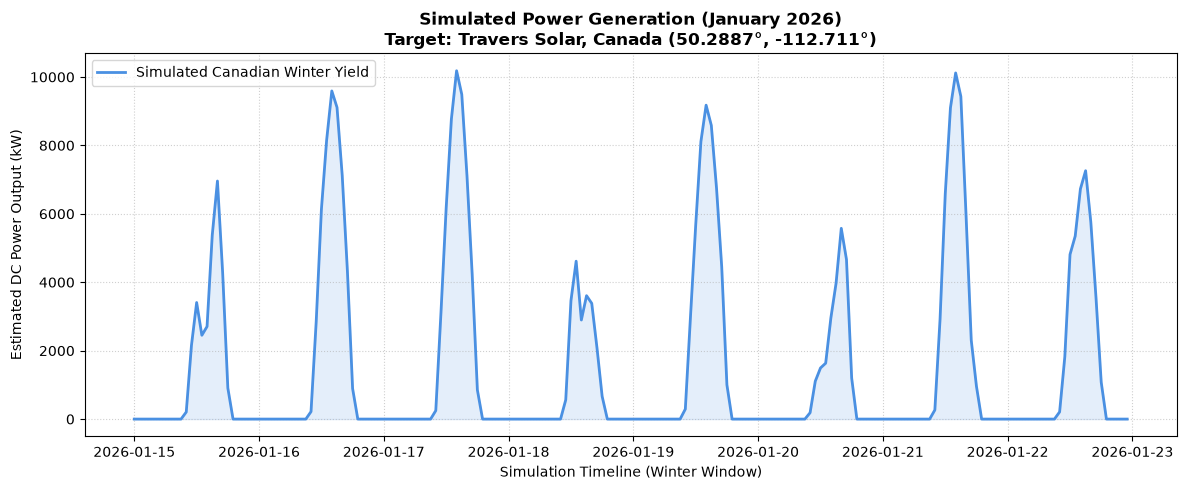

In [154]:
# Target Coordinates: Alberta, Canada
SIM_LAT = 50.2887
SIM_LON = -112.7110

# Fetch historical winter weather drivers (January 2026)
url_sim = f"https://archive-api.open-meteo.com/v1/archive?latitude={SIM_LAT}&longitude={SIM_LON}&start_date=2026-01-15&end_date=2026-01-22&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_sim).json()['hourly']

# Build the simulation dataframe
sim_profile = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Thermodynamic Module Simulation
sim_profile['MODULE_TEMPERATURE(°C)'] = sim_profile['AMBIENT_TEMPERATURE(°C)'] + (sim_profile['IRRADIATION(W/m²)'] * 0.03)

hr = sim_profile['TIMESTAMP'].dt.hour + (sim_profile['TIMESTAMP'].dt.minute / 60.0)

sim_profile['HOUR_SIN'] = np.sin(2 * np.pi * hr / 24.0)
sim_profile['HOUR_COS'] = np.cos(2 * np.pi * hr / 24.0)

sim_profile['MONTH_SIN'] = np.sin(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)
sim_profile['MONTH_COS'] = np.cos(2 * np.pi * sim_profile['TIMESTAMP'].dt.month / 12.0)

X_sim = sim_profile[[
    'MODULE_TEMPERATURE(°C)', 
    'AMBIENT_TEMPERATURE(°C)',
    'HOUR_SIN', 'HOUR_COS', 
    'MONTH_SIN', 'MONTH_COS'
]]

# Isolate irradiation as the required physical scaling array
irr_sim = sim_profile['IRRADIATION(W/m²)']

sim_profile['PREDICTED_GENERATION(kW)'] = predict(xgb_engine, X_sim, irr_sim)

# Plot the Winter Canada Feasibility Yield Curve (2026)
plt.figure(figsize=(12, 5))
plt.plot(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#4a90e2', linewidth=2, label='Simulated Canadian Winter Yield')
plt.fill_between(sim_profile['TIMESTAMP'], sim_profile['PREDICTED_GENERATION(kW)'], color='#4a90e2', alpha=0.15)

plt.title(f'Simulated Power Generation (January 2026)\nTarget: Travers Solar, Canada ({SIM_LAT}°, {SIM_LON}°)', fontsize=12, fontweight='bold')
plt.xlabel('Simulation Timeline (Winter Window)')
plt.ylabel('Estimated DC Power Output (kW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


--- Year Round Simulated Annual Outputs ---
Year 2016 Total Annual Yield: 32,515.36 MWh
Year 2017 Total Annual Yield: 33,591.00 MWh
Year 2018 Total Annual Yield: 32,660.57 MWh
Year 2019 Total Annual Yield: 32,401.14 MWh
Year 2020 Total Annual Yield: 32,634.68 MWh
Year 2021 Total Annual Yield: 33,294.23 MWh
Year 2022 Total Annual Yield: 32,704.67 MWh
Year 2023 Total Annual Yield: 32,929.00 MWh
Year 2024 Total Annual Yield: 32,713.44 MWh
Year 2025 Total Annual Yield: 32,752.83 MWh

--- Decadal Statistics (Annualized) ---
P50 (Median Expected Annual Yield): 32,709.06 MWh/year
P90 (Bankable Annual Yield): 32,243.21 MWh/year


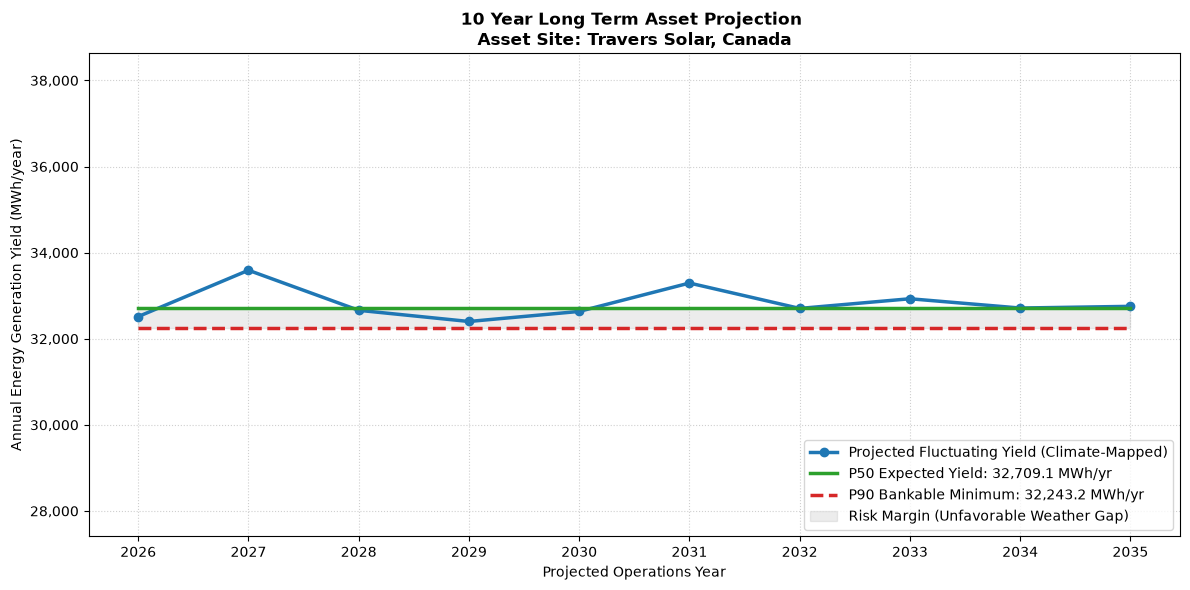

In [155]:
# Coordinates: Travers Solar, Canada
LAT = 50.2887
LON = -112.7110

# Fetch all year round hourly data for the past decade (2016-2025)
url_decade = f"https://archive-api.open-meteo.com/v1/archive?latitude={LAT}&longitude={LON}&start_date=2016-01-01&end_date=2025-12-31&hourly=temperature_2m,shortwave_radiation&timezone=auto"
res = requests.get(url_decade).json()['hourly']

# Build DataFrame
df_decade = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)': res['temperature_2m'],
    'IRRADIATION(W/m²)': res['shortwave_radiation']
})

# Filter out night hours
df_decade = df_decade[df_decade['IRRADIATION(W/m²)'] > 1.0].reset_index(drop=True)

# Calculate physical thermodynamic module heating
df_decade['MODULE_TEMPERATURE(°C)'] = df_decade['AMBIENT_TEMPERATURE(°C)'] + (df_decade['IRRADIATION(W/m²)'] * 0.03)

# Engineer cyclical time features for the upgraded model
hr = df_decade['TIMESTAMP'].dt.hour + (df_decade['TIMESTAMP'].dt.minute / 60.0)

df_decade['HOUR_SIN'] = np.sin(2 * np.pi * hr / 24.0)
df_decade['HOUR_COS'] = np.cos(2 * np.pi * hr / 24.0)

df_decade['MONTH_SIN'] = np.sin(2 * np.pi * df_decade['TIMESTAMP'].dt.month / 12.0)
df_decade['MONTH_COS'] = np.cos(2 * np.pi * df_decade['TIMESTAMP'].dt.month / 12.0)

X_decade = df_decade[[
    'MODULE_TEMPERATURE(°C)', 
    'AMBIENT_TEMPERATURE(°C)',
    'HOUR_SIN', 'HOUR_COS', 
    'MONTH_SIN', 'MONTH_COS'
]]

# Isolate irradiation as the required physical scaling array
irr_decade = df_decade['IRRADIATION(W/m²)']

df_decade['PREDICTED_GENERATION(kW)'] = predict(xgb_engine, X_decade, irr_decade)

# Group by calendar year and sum hourly generation to get Total Annual Yield (MWh)
df_decade['YEAR'] = df_decade['TIMESTAMP'].dt.year
annual_yields = df_decade.groupby('YEAR')['PREDICTED_GENERATION(kW)'].sum() / 1000.0

print("\n--- Year Round Simulated Annual Outputs ---")
for yr, yield_mwh in annual_yields.items():
    print(f"Year {yr} Total Annual Yield: {yield_mwh:,.2f} MWh")

# Calculate True Year-Round Decadal P50 & P90 using a strict median baseline
p50_annual = annual_yields.median()
std_dev_annual = annual_yields.std()
p90_annual = p50_annual - (1.282 * std_dev_annual)

print(f"\n--- Decadal Statistics (Annualized) ---")
print(f"P50 (Median Expected Annual Yield): {p50_annual:,.2f} MWh/year")
print(f"P90 (Bankable Annual Yield): {p90_annual:,.2f} MWh/year")

# Plot the 10-Year Future Horizon
future_years = [str(y) for y in range(2026, 2036)]

# Walk the future horizon years through the corresponding historical weather variations (up and down)
fluctuating_future_yields = [annual_yields.iloc[i % len(annual_yields)] for i in range(10)]

plt.figure(figsize=(12, 6))

# Plot the fluctuating prediction generation line
plt.plot(future_years, fluctuating_future_yields, color='#1f77b4', marker='o', linewidth=2.5,
         label='Projected Fluctuating Yield (Climate-Mapped)')

# Plot P50 Target Line
plt.plot(future_years, [p50_annual] * 10, color='#2ca02c', linestyle='-', linewidth=2.5, 
         label=f'P50 Expected Yield: {p50_annual:,.1f} MWh/yr')

# Plot P90 Target Line
plt.plot(future_years, [p90_annual] * 10, color='#d62728', linestyle='--', linewidth=2.5, 
         label=f'P90 Bankable Minimum: {p90_annual:,.1f} MWh/yr')

# Fill the statistical weather risk gap
plt.fill_between(future_years, [p90_annual] * 10, [p50_annual] * 10, color='gray', alpha=0.15, 
                 label='Risk Margin (Unfavorable Weather Gap)')

plt.title('10 Year Long Term Asset Projection \nAsset Site: Travers Solar, Canada', fontsize=12, fontweight='bold')
plt.xlabel('Projected Operations Year')
plt.ylabel('Annual Energy Generation Yield (MWh/year)')

# Set limits dynamically to fit the maximum peak of the historical fluctuations
plt.ylim(p90_annual * 0.85, max(max(fluctuating_future_yields), p50_annual) * 1.15)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()